# 07 — Latent Manipulation
**Dự án:** Latent Manipulation of Brain MRI using Volume-Preserving GANs

**Mục tiêu:** Sinh ảnh não ở các tuổi khác nhau bằng cách thay đổi age input của GAN.

**Output:**
```
latent_manipulation/
├── 2d_aging_simulation.png   ← 3 subjects × 5 target ages (2D)
└── 3d_aging_simulation.png   ← 3 subjects × 5 target ages (3D, axial mid-slice)
```


## Bước 1: Cấu hình

In [1]:
import os, json

# ==== MODEL 2D ====
COMPARE_2D_JSON   = '/kaggle/input/datasets/minhbodoi/compare-2d/comparison_result.json'
MODEL_2D_NORM     = '/kaggle/input/datasets/cminhnguyndsdsds/conditional-gan2d-normalized/best_model.pth'
MODEL_2D_UNNORM   = '/kaggle/input/datasets/dyio147/conditional-gan2d-unnormalized/best_model.pth'

# ==== MODEL 3D ====
COMPARE_3D_JSON   = '/kaggle/input/datasets/minhbodoi/compare-3d/comparison_result.json'
MODEL_3D_NORM     = '/kaggle/input/datasets/cminhnguyndsdsds/conditional-gan3d-normalized/best_model.pth'
MODEL_3D_UNNORM   = '/kaggle/input/datasets/dyio147/conditional-gan3d-unnormalized/best_model.pth'

# ==== DATA ====
DATA_2D_NORM_DIR   = '/kaggle/input/datasets/minhbodoi/full-preprocessed-2d/preprocessed_2d/normalized'
DATA_2D_UNNORM_DIR = '/kaggle/input/datasets/minhbodoi/full-preprocessed-2d/preprocessed_2d/unnormalized'
DATA_3D_NORM_DIR   = '/kaggle/input/datasets/minhbodoi/3000-preprocessed-3d/preprocessed_3d/normalized'
DATA_3D_UNNORM_DIR = '/kaggle/input/datasets/minhbodoi/3000-preprocessed-3d/preprocessed_3d/unnormalized'
LABELS_2D_CSV      = '/kaggle/input/datasets/minhbodoi/full-preprocessed-2d/preprocessed_2d/preprocessing_log.csv'
LABELS_3D_CSV      = '/kaggle/input/datasets/minhbodoi/3000-preprocessed-3d/preprocessed_3d/preprocessing_log.csv'

OUTPUT_DIR = '/kaggle/working/latent_manipulation'
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET_AGES = [20, 30, 40, 50, 60, 70, 80]
LATENT_DIM  = 256
N_SAMPLES   = 300  # số subject dùng để fit direction vector

with open(COMPARE_2D_JSON) as f: winner_2d = json.load(f)['winner']
with open(COMPARE_3D_JSON) as f: winner_3d = json.load(f)['winner']

MODEL_2D_PATH = MODEL_2D_NORM    if winner_2d == 'normalized' else MODEL_2D_UNNORM
MODEL_3D_PATH = MODEL_3D_NORM    if winner_3d == 'normalized' else MODEL_3D_UNNORM
DATA_2D_DIR   = DATA_2D_NORM_DIR if winner_2d == 'normalized' else DATA_2D_UNNORM_DIR
DATA_3D_DIR   = DATA_3D_NORM_DIR if winner_3d == 'normalized' else DATA_3D_UNNORM_DIR

print(f'Winner 2D: {winner_2d}')
print(f'Winner 3D: {winner_3d}')


Winner 2D: normalized
Winner 3D: unnormalized


## Bước 2: Import thư viện

In [2]:
!pip install nibabel -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
from PIL import Image
import torchvision.transforms as transforms
import warnings
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


## Bước 3: Định nghĩa kiến trúc model

In [3]:
class AgeEmbedding(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 128), nn.ReLU(),
            nn.Linear(128, embed_dim)
        )
    def forward(self, age):
        return self.net(age.unsqueeze(-1))


# ===== 2D =====
class UNetBlock2D(nn.Module):
    def __init__(self, in_ch, out_ch, down=True, use_bn=True, dropout=False):
        super().__init__()
        layers = []
        if down : layers.append(nn.Conv2d(in_ch, out_ch, 4, 2, 1, bias=False))
        else    : layers.append(nn.ConvTranspose2d(in_ch, out_ch, 4, 2, 1, bias=False))
        if use_bn  : layers.append(nn.BatchNorm2d(out_ch))
        if dropout : layers.append(nn.Dropout(0.5))
        layers.append(nn.LeakyReLU(0.2) if down else nn.ReLU())
        self.block = nn.Sequential(*layers)
    def forward(self, x): return self.block(x)


class Generator2D(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.age_embed = AgeEmbedding(latent_dim)
        self.age_proj  = nn.Linear(latent_dim, 512)
        self.e1 = UNetBlock2D(1,   64,  down=True, use_bn=False)
        self.e2 = UNetBlock2D(64,  128, down=True)
        self.e3 = UNetBlock2D(128, 256, down=True)
        self.e4 = UNetBlock2D(256, 512, down=True)
        self.e5 = UNetBlock2D(512, 512, down=True)
        self.e6 = UNetBlock2D(512, 512, down=True)
        self.e7 = UNetBlock2D(512, 512, down=True)
        self.e8 = UNetBlock2D(512, 512, down=True, use_bn=False)
        self.d1 = UNetBlock2D(512,  512, down=False, dropout=True)
        self.d2 = UNetBlock2D(1024, 512, down=False, dropout=True)
        self.d3 = UNetBlock2D(1024, 512, down=False, dropout=True)
        self.d4 = UNetBlock2D(1024, 512, down=False)
        self.d5 = UNetBlock2D(1024, 256, down=False)
        self.d6 = UNetBlock2D(512,  128, down=False)
        self.d7 = UNetBlock2D(256,  64,  down=False)
        self.out = nn.Sequential(nn.ConvTranspose2d(128, 1, 4, 2, 1), nn.Tanh())

    def forward(self, x, age):
        e1=self.e1(x); e2=self.e2(e1); e3=self.e3(e2); e4=self.e4(e3)
        e5=self.e5(e4); e6=self.e6(e5); e7=self.e7(e6); e8=self.e8(e7)
        z = e8 + self.age_proj(self.age_embed(age)).view(-1, 512, 1, 1)
        d1=self.d1(z)
        d2=self.d2(torch.cat([d1,e7],dim=1))
        d3=self.d3(torch.cat([d2,e6],dim=1))
        d4=self.d4(torch.cat([d3,e5],dim=1))
        d5=self.d5(torch.cat([d4,e4],dim=1))
        d6=self.d6(torch.cat([d5,e3],dim=1))
        d7=self.d7(torch.cat([d6,e2],dim=1))
        return self.out(torch.cat([d7,e1],dim=1))

    def encode(self, x, age):
        """Trả về bottleneck z — dùng để examine/manipulate latent space."""
        e1=self.e1(x); e2=self.e2(e1); e3=self.e3(e2); e4=self.e4(e3)
        e5=self.e5(e4); e6=self.e6(e5); e7=self.e7(e6); e8=self.e8(e7)
        z = e8 + self.age_proj(self.age_embed(age)).view(-1, 512, 1, 1)
        return z.squeeze(-1).squeeze(-1)  # (B, 512)


# ===== 3D =====
class UNetBlock3D(nn.Module):
    def __init__(self, in_ch, out_ch, down=True, use_bn=True, dropout=False):
        super().__init__()
        layers = []
        if down : layers.append(nn.Conv3d(in_ch, out_ch, 4, 2, 1, bias=False))
        else    : layers.append(nn.ConvTranspose3d(in_ch, out_ch, 4, 2, 1, bias=False))
        if use_bn  : layers.append(nn.BatchNorm3d(out_ch))
        if dropout : layers.append(nn.Dropout(0.5))
        layers.append(nn.LeakyReLU(0.2) if down else nn.ReLU())
        self.block = nn.Sequential(*layers)
    def forward(self, x): return self.block(x)


class Generator3D(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.age_embed = AgeEmbedding(latent_dim)
        self.age_proj  = nn.Linear(latent_dim, 256)
        self.e1 = UNetBlock3D(1,   32,  down=True, use_bn=False)
        self.e2 = UNetBlock3D(32,  64,  down=True)
        self.e3 = UNetBlock3D(64,  128, down=True)
        self.e4 = UNetBlock3D(128, 256, down=True, use_bn=False)
        self.d1 = UNetBlock3D(256, 128, down=False, dropout=True)
        self.d2 = UNetBlock3D(256, 64,  down=False)
        self.d3 = UNetBlock3D(128, 32,  down=False)
        self.out = nn.Sequential(nn.ConvTranspose3d(64, 1, 4, 2, 1), nn.Tanh())

    def forward(self, x, age):
        e1=self.e1(x); e2=self.e2(e1); e3=self.e3(e2); e4=self.e4(e3)
        z = e4 + self.age_proj(self.age_embed(age)).view(-1, 256, 1, 1, 1)
        d1=self.d1(z)
        d2=self.d2(torch.cat([d1,e3],dim=1))
        d3=self.d3(torch.cat([d2,e2],dim=1))
        return self.out(torch.cat([d3,e1],dim=1))

    def encode(self, x, age):
        """Trả về bottleneck z 3D."""
        e1=self.e1(x); e2=self.e2(e1); e3=self.e3(e2); e4=self.e4(e3)
        z = e4 + self.age_proj(self.age_embed(age)).view(-1, 256, 1, 1, 1)
        return z.mean(dim=[-3,-2,-1])  # (B, 256)


print('Kiến trúc model định nghĩa xong!')

# ── StyleGAN classes ──────────────────────────────────────────
class MappingNetwork(nn.Module):
    def __init__(self, latent_dim=256, w_dim=512, n_layers=4):
        super().__init__()
        layers = [AgeEmbedding(latent_dim), nn.ReLU()]
        in_dim = latent_dim
        for _ in range(n_layers - 1):
            layers += [nn.Linear(in_dim, w_dim), nn.ReLU()]
            in_dim = w_dim
        self.net = nn.Sequential(*layers)
        self.out = nn.Linear(in_dim, w_dim)
    def forward(self, age): return self.out(self.net(age))

class AdaIN2D(nn.Module):
    def __init__(self, channels, w_dim=512):
        super().__init__()
        self.norm  = nn.InstanceNorm2d(channels, affine=False)
        self.style = nn.Linear(w_dim, channels * 2)
    def forward(self, x, w):
        style = self.style(w).unsqueeze(-1).unsqueeze(-1)
        scale, shift = style.chunk(2, dim=1)
        return scale * self.norm(x) + shift

class Generator2D_StyleGAN(nn.Module):
    def __init__(self, latent_dim=256, w_dim=512):
        super().__init__()
        self.mapping = MappingNetwork(latent_dim, w_dim)
        self.e1=UNetBlock2D(1,64,down=True,use_bn=False); self.e2=UNetBlock2D(64,128,down=True)
        self.e3=UNetBlock2D(128,256,down=True); self.e4=UNetBlock2D(256,512,down=True)
        self.e5=UNetBlock2D(512,512,down=True); self.e6=UNetBlock2D(512,512,down=True)
        self.e7=UNetBlock2D(512,512,down=True); self.e8=UNetBlock2D(512,512,down=True,use_bn=False)
        self.d1=nn.Sequential(nn.ConvTranspose2d(512,512,4,2,1,bias=False),nn.Dropout(0.5),nn.ReLU())
        self.d2=nn.Sequential(nn.ConvTranspose2d(1024,512,4,2,1,bias=False),nn.Dropout(0.5),nn.ReLU())
        self.d3=nn.Sequential(nn.ConvTranspose2d(1024,512,4,2,1,bias=False),nn.Dropout(0.5),nn.ReLU())
        self.d4=nn.Sequential(nn.ConvTranspose2d(1024,512,4,2,1,bias=False),nn.ReLU())
        self.d5=nn.Sequential(nn.ConvTranspose2d(1024,256,4,2,1,bias=False),nn.ReLU())
        self.d6=nn.Sequential(nn.ConvTranspose2d(512,128,4,2,1,bias=False),nn.ReLU())
        self.d7=nn.Sequential(nn.ConvTranspose2d(256,64,4,2,1,bias=False),nn.ReLU())
        self.out=nn.Sequential(nn.ConvTranspose2d(128,1,4,2,1),nn.Tanh())
        self.adain1=AdaIN2D(512,w_dim); self.adain2=AdaIN2D(512,w_dim)
        self.adain3=AdaIN2D(512,w_dim); self.adain4=AdaIN2D(512,w_dim)
        self.adain5=AdaIN2D(256,w_dim); self.adain6=AdaIN2D(128,w_dim)
        self.adain7=AdaIN2D(64,w_dim)
    def forward(self, x, age):
        w=self.mapping(age)
        e1=self.e1(x); e2=self.e2(e1); e3=self.e3(e2); e4=self.e4(e3)
        e5=self.e5(e4); e6=self.e6(e5); e7=self.e7(e6); e8=self.e8(e7)
        d1=self.adain1(self.d1(e8),w); d2=self.adain2(self.d2(torch.cat([d1,e7],1)),w)
        d3=self.adain3(self.d3(torch.cat([d2,e6],1)),w); d4=self.adain4(self.d4(torch.cat([d3,e5],1)),w)
        d5=self.adain5(self.d5(torch.cat([d4,e4],1)),w); d6=self.adain6(self.d6(torch.cat([d5,e3],1)),w)
        d7=self.adain7(self.d7(torch.cat([d6,e2],1)),w)
        return self.out(torch.cat([d7,e1],1))
    def encode(self, x, age): return self.mapping(age)
    def decode_from_w(self, x, w):
        e1=self.e1(x); e2=self.e2(e1); e3=self.e3(e2); e4=self.e4(e3)
        e5=self.e5(e4); e6=self.e6(e5); e7=self.e7(e6); e8=self.e8(e7)
        d1=self.adain1(self.d1(e8),w); d2=self.adain2(self.d2(torch.cat([d1,e7],1)),w)
        d3=self.adain3(self.d3(torch.cat([d2,e6],1)),w); d4=self.adain4(self.d4(torch.cat([d3,e5],1)),w)
        d5=self.adain5(self.d5(torch.cat([d4,e4],1)),w); d6=self.adain6(self.d6(torch.cat([d5,e3],1)),w)
        d7=self.adain7(self.d7(torch.cat([d6,e2],1)),w)
        return self.out(torch.cat([d7,e1],1))

class MappingNetwork3D(nn.Module):
    def __init__(self, latent_dim=256, w_dim=256, n_layers=4):
        super().__init__()
        layers = [AgeEmbedding(latent_dim), nn.ReLU()]
        in_dim = latent_dim
        for _ in range(n_layers - 1):
            layers += [nn.Linear(in_dim, w_dim), nn.ReLU()]
            in_dim = w_dim
        self.net = nn.Sequential(*layers)
        self.out = nn.Linear(in_dim, w_dim)
    def forward(self, age): return self.out(self.net(age))

class AdaIN3D(nn.Module):
    def __init__(self, channels, w_dim=256):
        super().__init__()
        self.norm  = nn.InstanceNorm3d(channels, affine=False)
        self.style = nn.Linear(w_dim, channels * 2)
    def forward(self, x, w):
        style = self.style(w).unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)
        scale, shift = style.chunk(2, dim=1)
        return scale * self.norm(x) + shift

class Generator3D_StyleGAN(nn.Module):
    def __init__(self, latent_dim=256, w_dim=256):
        super().__init__()
        self.mapping = MappingNetwork3D(latent_dim, w_dim)
        self.e1=UNetBlock3D(1,32,down=True,use_bn=False); self.e2=UNetBlock3D(32,64,down=True)
        self.e3=UNetBlock3D(64,128,down=True); self.e4=UNetBlock3D(128,256,down=True,use_bn=False)
        self.d1=nn.Sequential(nn.ConvTranspose3d(256,128,4,2,1,bias=False),nn.Dropout(0.5),nn.ReLU())
        self.d2=nn.Sequential(nn.ConvTranspose3d(256,64,4,2,1,bias=False),nn.ReLU())
        self.d3=nn.Sequential(nn.ConvTranspose3d(128,32,4,2,1,bias=False),nn.ReLU())
        self.out=nn.Sequential(nn.ConvTranspose3d(64,1,4,2,1),nn.Tanh())
        self.adain1=AdaIN3D(128,w_dim); self.adain2=AdaIN3D(64,w_dim); self.adain3=AdaIN3D(32,w_dim)
    def forward(self, x, age):
        w=self.mapping(age)
        e1=self.e1(x); e2=self.e2(e1); e3=self.e3(e2); e4=self.e4(e3)
        d1=self.adain1(self.d1(e4),w); d2=self.adain2(self.d2(torch.cat([d1,e3],1)),w)
        d3=self.adain3(self.d3(torch.cat([d2,e2],1)),w)
        return self.out(torch.cat([d3,e1],1))
    def encode(self, x, age): return self.mapping(age)
    def decode_from_w(self, x, w):
        e1=self.e1(x); e2=self.e2(e1); e3=self.e3(e2); e4=self.e4(e3)
        sp = e4.shape[2:]
        z_s = w.unsqueeze(-1).unsqueeze(-1).unsqueeze(-1).expand(-1,-1,*sp)
        d1=self.adain1(self.d1(z_s),w); d2=self.adain2(self.d2(torch.cat([d1,e3],1)),w)
        d3=self.adain3(self.d3(torch.cat([d2,e2],1)),w)
        return self.out(torch.cat([d3,e1],1))


# ── Kiến trúc Concat (age_fuse) ───────────────────────────────
class Generator2D_Concat(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.age_embed = AgeEmbedding(latent_dim)
        self.age_proj  = nn.Linear(latent_dim, 512)
        self.age_fuse  = nn.Conv2d(1024, 512, 1)
        self.e1=UNetBlock2D(1,64,down=True,use_bn=False); self.e2=UNetBlock2D(64,128,down=True)
        self.e3=UNetBlock2D(128,256,down=True); self.e4=UNetBlock2D(256,512,down=True)
        self.e5=UNetBlock2D(512,512,down=True); self.e6=UNetBlock2D(512,512,down=True)
        self.e7=UNetBlock2D(512,512,down=True); self.e8=UNetBlock2D(512,512,down=True,use_bn=False)
        self.d1=UNetBlock2D(512,512,down=False,dropout=True); self.d2=UNetBlock2D(1024,512,down=False,dropout=True)
        self.d3=UNetBlock2D(1024,512,down=False,dropout=True); self.d4=UNetBlock2D(1024,512,down=False)
        self.d5=UNetBlock2D(1024,256,down=False); self.d6=UNetBlock2D(512,128,down=False)
        self.d7=UNetBlock2D(256,64,down=False)
        self.out=nn.Sequential(nn.ConvTranspose2d(128,1,4,2,1),nn.Tanh())
    def forward(self, x, age):
        e1=self.e1(x); e2=self.e2(e1); e3=self.e3(e2); e4=self.e4(e3)
        e5=self.e5(e4); e6=self.e6(e5); e7=self.e7(e6); e8=self.e8(e7)
        age_feat=self.age_proj(self.age_embed(age)).view(-1,512,1,1).expand_as(e8)
        z=self.age_fuse(torch.cat([e8,age_feat],dim=1))
        d1=self.d1(z); d2=self.d2(torch.cat([d1,e7],1)); d3=self.d3(torch.cat([d2,e6],1))
        d4=self.d4(torch.cat([d3,e5],1)); d5=self.d5(torch.cat([d4,e4],1))
        d6=self.d6(torch.cat([d5,e3],1)); d7=self.d7(torch.cat([d6,e2],1))
        return self.out(torch.cat([d7,e1],1))
    def encode(self, x, age):
        e1=self.e1(x); e2=self.e2(e1); e3=self.e3(e2); e4=self.e4(e3)
        e5=self.e5(e4); e6=self.e6(e5); e7=self.e7(e6); e8=self.e8(e7)
        age_feat=self.age_proj(self.age_embed(age)).view(-1,512,1,1).expand_as(e8)
        return self.age_fuse(torch.cat([e8,age_feat],dim=1)).squeeze(-1).squeeze(-1).mean(dim=[-2,-1]) if e8.shape[-1]>1 else self.age_fuse(torch.cat([e8,age_feat],dim=1)).squeeze(-1).squeeze(-1)

class Generator3D_Concat(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.age_embed = AgeEmbedding(latent_dim)
        self.age_proj  = nn.Linear(latent_dim, 256)
        self.age_fuse  = nn.Conv3d(512, 256, 1)
        self.e1=UNetBlock3D(1,32,down=True,use_bn=False); self.e2=UNetBlock3D(32,64,down=True)
        self.e3=UNetBlock3D(64,128,down=True); self.e4=UNetBlock3D(128,256,down=True,use_bn=False)
        self.d1=UNetBlock3D(256,128,down=False,dropout=True)
        self.d2=UNetBlock3D(256,64,down=False); self.d3=UNetBlock3D(128,32,down=False)
        self.out=nn.Sequential(nn.ConvTranspose3d(64,1,4,2,1),nn.Tanh())
    def forward(self, x, age):
        e1=self.e1(x); e2=self.e2(e1); e3=self.e3(e2); e4=self.e4(e3)
        age_feat=self.age_proj(self.age_embed(age)).view(-1,256,1,1,1).expand_as(e4)
        z=self.age_fuse(torch.cat([e4,age_feat],dim=1))
        d1=self.d1(z); d2=self.d2(torch.cat([d1,e3],1)); d3=self.d3(torch.cat([d2,e2],1))
        return self.out(torch.cat([d3,e1],1))
    def encode(self, x, age):
        e1=self.e1(x); e2=self.e2(e1); e3=self.e3(e2); e4=self.e4(e3)
        age_feat=self.age_proj(self.age_embed(age)).view(-1,256,1,1,1).expand_as(e4)
        return self.age_fuse(torch.cat([e4,age_feat],dim=1)).mean(dim=[-3,-2,-1])


Kiến trúc model định nghĩa xong!


## Bước 4: Load model tốt nhất

In [4]:
def auto_load_2d(path):
    ckpt = torch.load(path, map_location=DEVICE)
    keys = list(ckpt['G_state'].keys())
    if any('mapping' in k for k in keys):
        G = Generator2D_StyleGAN(LATENT_DIM).to(DEVICE)
    elif any('age_fuse' in k for k in keys):
        G = Generator2D_Concat(LATENT_DIM).to(DEVICE)
    else:
        G = Generator2D(LATENT_DIM).to(DEVICE)
    G.load_state_dict(ckpt['G_state']); G.eval()
    return G, ckpt

def auto_load_3d(path):
    ckpt = torch.load(path, map_location=DEVICE)
    keys = list(ckpt['G_state'].keys())
    if any('mapping' in k for k in keys):
        G = Generator3D_StyleGAN(LATENT_DIM).to(DEVICE)
    elif any('age_fuse' in k for k in keys):
        G = Generator3D_Concat(LATENT_DIM).to(DEVICE)
    else:
        G = Generator3D(LATENT_DIM).to(DEVICE)
    G.load_state_dict(ckpt['G_state']); G.eval()
    return G, ckpt

G2D, ckpt_2d = auto_load_2d(MODEL_2D_PATH)
G3D, ckpt_3d = auto_load_3d(MODEL_3D_PATH)

print(f'GAN 2D ({winner_2d}) loaded | best_val_SSIM: {ckpt_2d.get("best_val_ssim",-1):.4f}')
print(f'GAN 3D ({winner_3d}) loaded | best_val_SSIM: {ckpt_3d.get("best_val_ssim",-1):.4f}')


GAN 2D (normalized) loaded | best_val_SSIM: 0.9778
GAN 3D (unnormalized) loaded | best_val_SSIM: 0.9805


## Bước 5: Latent Manipulation — GAN 2D

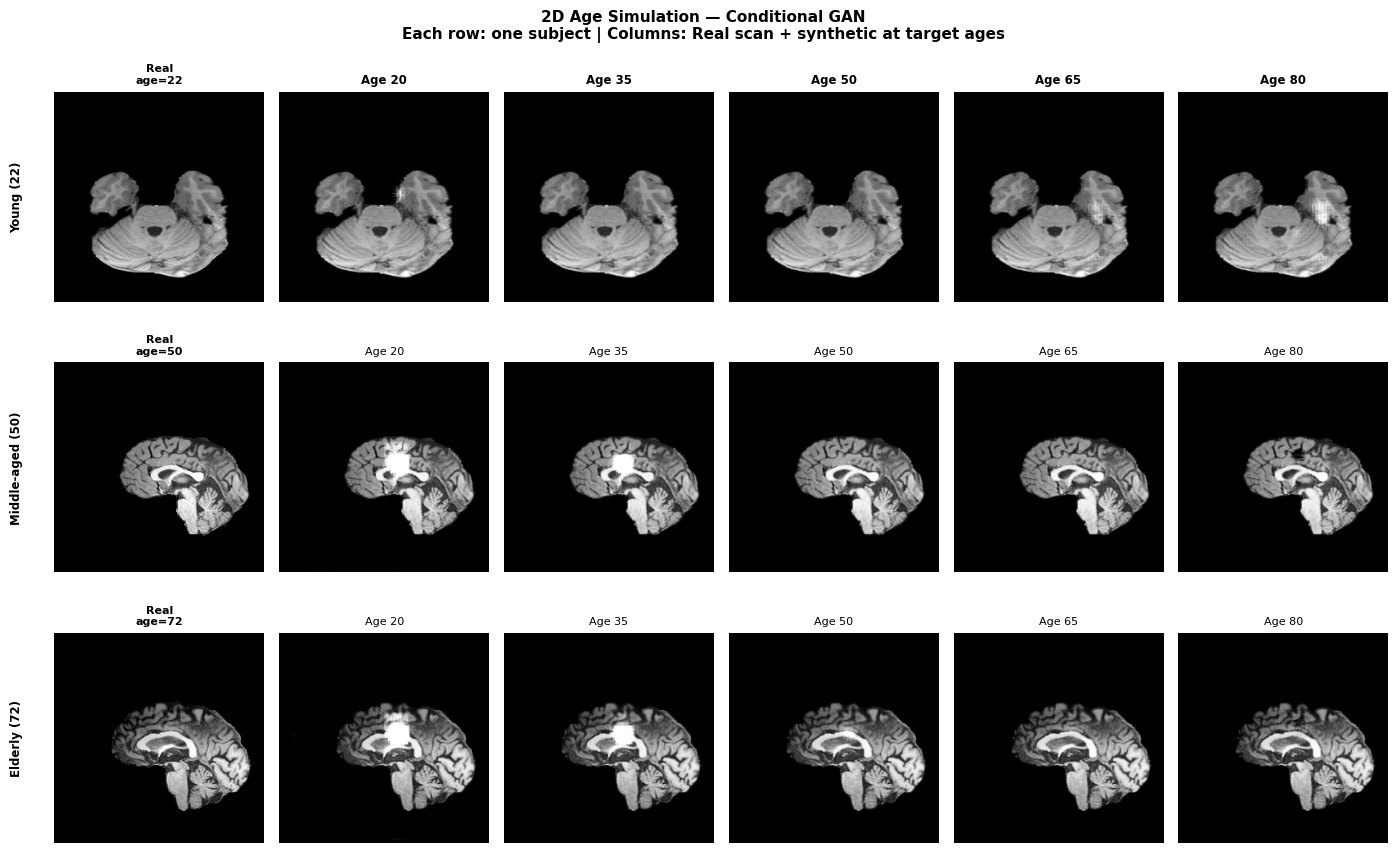

GAN 2D aging simulation saved.


In [5]:
# ── Latent Manipulation — GAN 2D ─────────────────────────────
# Một figure duy nhất: 3 subjects (rows) × (Real + 5 target ages) (cols)
from sklearn.linear_model import LinearRegression
import torchvision.transforms as transforms

df_2d = pd.read_csv(LABELS_2D_CSV)
df_2d['full_path'] = df_2d['png_file'].apply(lambda x: os.path.join(DATA_2D_DIR, x))
df_2d = df_2d[df_2d['full_path'].apply(os.path.exists)].reset_index(drop=True)

transform = transforms.Compose([
    transforms.Resize((256,256)), transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

def normalize_age_2d(age):
    return 2*(age-ckpt_2d['age_min'])/(ckpt_2d['age_max']-ckpt_2d['age_min'])-1

# Tìm 3 subject đại diện
subjects_2d = []
for age_target, label in [(22,'Young (22)'), (50,'Middle-aged (50)'), (72,'Elderly (72)')]:
    idx = (df_2d['age'] - age_target).abs().idxmin()
    subjects_2d.append((df_2d.loc[idx,'full_path'], df_2d.loc[idx,'age'], label))

# Target ages hiển thị — chỉ 5 mốc đại diện
SHOW_AGES = [20, 35, 50, 65, 80]

G2D.eval()
fig, axes = plt.subplots(3, len(SHOW_AGES)+1, figsize=(14, 9))
fig.suptitle('2D Age Simulation — Conditional GAN\n'
             'Each row: one subject | Columns: Real scan + synthetic at target ages',
             fontsize=11, fontweight='bold')

for row_i, (png_path, age_orig, label) in enumerate(subjects_2d):
    img = transform(Image.open(png_path).convert('L')).unsqueeze(0).to(DEVICE)
    orig_np = (img[0,0].cpu().numpy() + 1) / 2

    # Col 0: ảnh gốc
    axes[row_i][0].imshow(orig_np, cmap='gray')
    axes[row_i][0].set_title(f'Real\nage={age_orig:.0f}', fontsize=8, fontweight='bold')
    axes[row_i][0].axis('off')
    axes[row_i][0].set_ylabel(label, fontsize=8)

    # Vertical label cho subject
    axes[row_i][0].text(-0.15, 0.5, label, transform=axes[row_i][0].transAxes,
                        va='center', ha='right', fontsize=8.5,
                        fontweight='bold', rotation=90)

    # Col 1-5: conditional synthesis
    with torch.no_grad():
        for col_i, ta in enumerate(SHOW_AGES):
            age_t = torch.tensor([normalize_age_2d(ta)], dtype=torch.float32).to(DEVICE)
            fake  = G2D(img, age_t)
            fake_np = (fake[0,0].cpu().numpy() + 1) / 2
            axes[row_i][col_i+1].imshow(fake_np, cmap='gray')
            axes[row_i][col_i+1].set_title(f'Age {ta}', fontsize=8)
            axes[row_i][col_i+1].axis('off')

# Column headers
for ci, ta in enumerate(SHOW_AGES):
    axes[0][ci+1].set_title(f'Age {ta}', fontsize=8.5, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/2d_aging_simulation.png', dpi=120, bbox_inches='tight')
plt.show()
print('GAN 2D aging simulation saved.')


## Bước 6: Latent Manipulation — GAN 3D

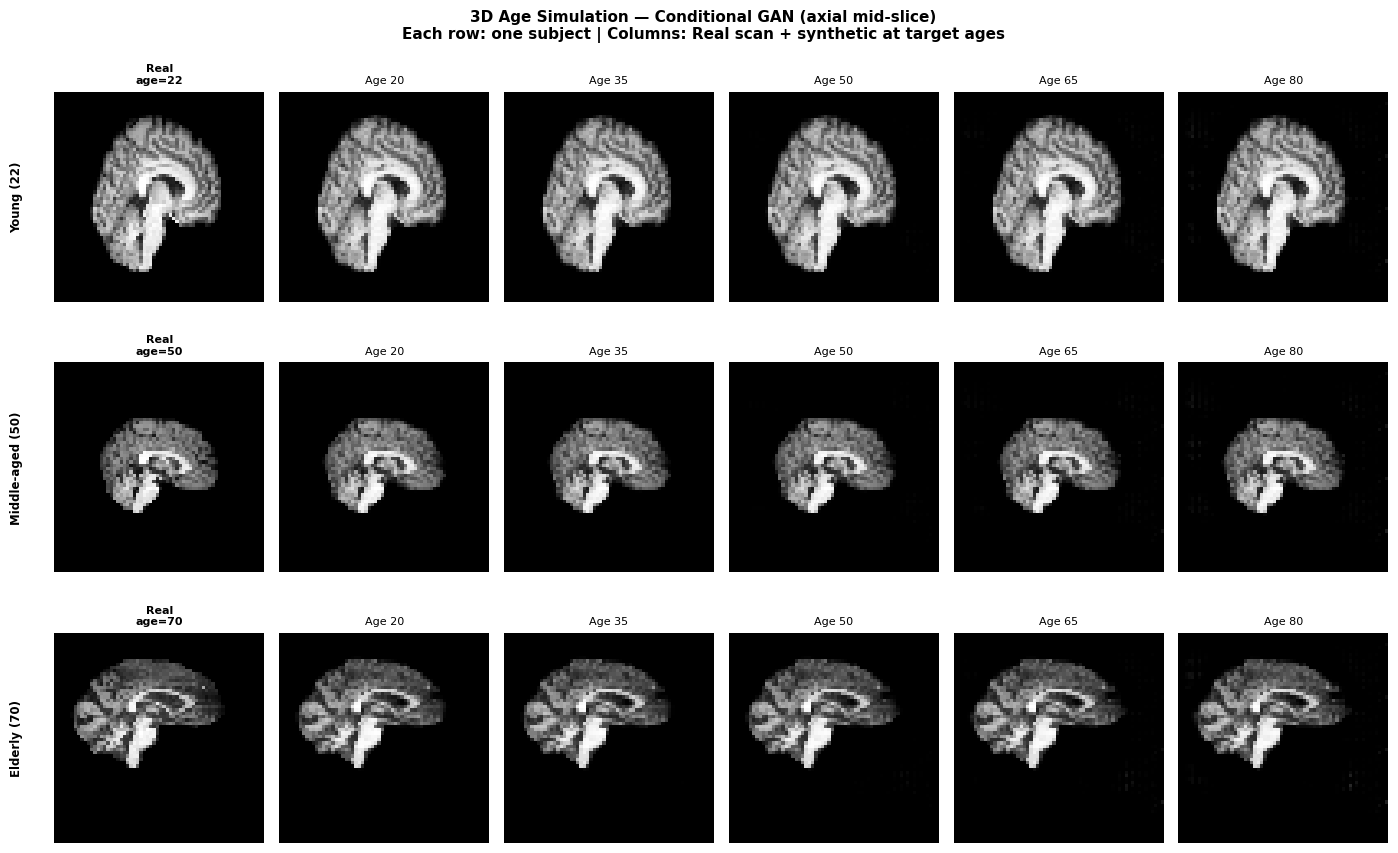

GAN 3D aging simulation saved.


In [6]:
# ── Latent Manipulation — GAN 3D ─────────────────────────────
# Một figure duy nhất: 3 subjects (rows) × (Real + 5 target ages) (cols)
# Chỉ hiển thị axial mid-slice của mỗi volume

df_3d = pd.read_csv(LABELS_3D_CSV)
volume_size = ckpt_3d.get('volume_size', 64)

def find_nii(data_dir, subject_id):
    for ext in ['.nii.gz', '.nii']:
        p = os.path.join(data_dir, f'{subject_id}{ext}')
        if os.path.exists(p): return p
    return None

def normalize_age_3d(age):
    return 2*(age-ckpt_3d['age_min'])/(ckpt_3d['age_max']-ckpt_3d['age_min'])-1

def load_vol(nii_path):
    data = nib.load(nii_path).get_fdata().astype(np.float32)
    vol  = torch.tensor(data).unsqueeze(0).unsqueeze(0)
    vol  = F.interpolate(vol, size=(volume_size,)*3, mode='trilinear', align_corners=False)
    return (vol.squeeze(0)*2-1).unsqueeze(0)

df_3d['nii_path'] = df_3d['subject_id'].apply(lambda x: find_nii(DATA_3D_DIR, x))
df_3d_valid = df_3d[df_3d['nii_path'].notna()].reset_index(drop=True)

subjects_3d = []
for age_target, label in [(22,'Young (22)'), (50,'Middle-aged (50)'), (70,'Elderly (70)')]:
    idx = (df_3d_valid['age'] - age_target).abs().idxmin()
    subjects_3d.append((df_3d_valid.loc[idx,'nii_path'],
                        df_3d_valid.loc[idx,'age'], label))

SHOW_AGES = [20, 35, 50, 65, 80]
mid = volume_size // 2

G3D.eval()
fig, axes = plt.subplots(3, len(SHOW_AGES)+1, figsize=(14, 9))
fig.suptitle('3D Age Simulation — Conditional GAN (axial mid-slice)\n'
             'Each row: one subject | Columns: Real scan + synthetic at target ages',
             fontsize=11, fontweight='bold')

for row_i, (nii_path, age_orig, label) in enumerate(subjects_3d):
    vol    = load_vol(nii_path).to(DEVICE)
    orig_np = (vol[0,0].cpu().numpy() + 1) / 2

    # Col 0: ảnh gốc (axial mid-slice)
    axes[row_i][0].imshow(orig_np[mid,:,:].T, cmap='gray', origin='lower')
    axes[row_i][0].set_title(f'Real\nage={age_orig:.0f}', fontsize=8, fontweight='bold')
    axes[row_i][0].axis('off')
    axes[row_i][0].text(-0.15, 0.5, label, transform=axes[row_i][0].transAxes,
                        va='center', ha='right', fontsize=8.5,
                        fontweight='bold', rotation=90)

    # Col 1-5: conditional synthesis
    with torch.no_grad():
        for col_i, ta in enumerate(SHOW_AGES):
            age_t = torch.tensor([normalize_age_3d(ta)], dtype=torch.float32).to(DEVICE)
            fake  = G3D(vol, age_t)
            fake_np = (fake[0,0].cpu().numpy() + 1) / 2
            axes[row_i][col_i+1].imshow(fake_np[mid,:,:].T, cmap='gray', origin='lower')
            axes[row_i][col_i+1].set_title(f'Age {ta}', fontsize=8)
            axes[row_i][col_i+1].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/3d_aging_simulation.png', dpi=120, bbox_inches='tight')
plt.show()
print('GAN 3D aging simulation saved.')
